# Fig. 4b: Open Data Score vs. Encoding Consistency

This notebook reproduces **Figure 4b** of the publication. It tests the hypothesis that stricter policies are harder to encode consistently by computing the Pearson correlation between the open data score and the encoding consistency rate per publisher (excluding questions 10 & 11).

In [2]:
import glob
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from collections import defaultdict
from daemon_analysis_tools.io.yaml_handler import load_answers_from_yaml
from daemon_analysis_tools.io.csv_handler import _load_csv

## Setup

Import analysis tools and configure matplotlib.

In [3]:
SMALL_SIZE = 8
MEDIUM_SIZE = 10
BIGGER_SIZE = 12
LINE_WIDTH = 1.5
MARKER_SIZE = 6

plt.rc("font", **{"family": "sans-serif", "sans-serif": ["Liberation Sans"]})
plt.rc("font", family="sans-serif", weight="bold", size=MEDIUM_SIZE)

plt.rc("axes", titlesize=MEDIUM_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)

mpl.rcParams["font.weight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
mpl.rcParams["mathtext.default"] = "regular"
mpl.rcParams["lines.linewidth"] = LINE_WIDTH
mpl.rcParams["lines.markersize"] = MARKER_SIZE

## Load processed data

In [4]:
# Load all the processed yaml files 
processed_data = load_answers_from_yaml('../../data/processed/all_answers/')


No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
No discrepancies detected.
N

## Compute consistency and scores per publisher

For each publisher, count the fraction of questions answered consistently by both encoders (excluding free-text questions 10 & 11). Then compute the average ODS and calculate the Pearson correlation.

In [5]:
inconsitencies_dict = {}

for publisher, journals in processed_data.items():
    n_question = 0
    inconsitencies = {"Consistent": 0, "Inconsistent": 0}

    for journal, data in journals.items():
        for question, answer in data.items():
            n_question += 1

            if question == "data_recommended" or question == "data_required":
                continue

            if not answer.has_multiple_answers():
                continue

            if answer.has_discrepancies():
                inconsitencies["Inconsistent"] += 1
            else:
                inconsitencies["Consistent"] += 1
    
    print(publisher, inconsitencies)
    inconsitencies_dict[publisher] = inconsitencies

ACS {'Consistent': 147, 'Inconsistent': 57}
AIP {'Consistent': 215, 'Inconsistent': 23}
APS {'Consistent': 183, 'Inconsistent': 4}
Bentham Science {'Consistent': 72, 'Inconsistent': 30}
Elsevier {'Consistent': 88, 'Inconsistent': 31}
Frontiers {'Consistent': 63, 'Inconsistent': 56}
IEEE {'Consistent': 225, 'Inconsistent': 30}
IOP {'Consistent': 139, 'Inconsistent': 14}
MDPI {'Consistent': 140, 'Inconsistent': 115}
Optica {'Consistent': 75, 'Inconsistent': 10}
Pleiades Publishing {'Consistent': 102, 'Inconsistent': 51}
RSC {'Consistent': 106, 'Inconsistent': 47}
Springer Nature {'Consistent': 116, 'Inconsistent': 54}
Taylor & Francis {'Consistent': 227, 'Inconsistent': 28}
Wiley {'Consistent': 167, 'Inconsistent': 88}
codata {'Consistent': 14, 'Inconsistent': 3}
open journals {'Consistent': 8, 'Inconsistent': 9}


In [6]:
from daemon_analysis_tools.services.scoring import get_journal_score
from scipy import stats
import numpy as np

inconsitency_list = []
score_list = []

for publisher, publisher_results in processed_data.items():
    inconsitency_list_0 = []
    score_list_0 = []

    for journal, journal_results in publisher_results.items():
        score = get_journal_score(journal_results)
        score_list_0.append(score)

    inconsitency = inconsitencies_dict[publisher]["Consistent"] / (inconsitencies_dict[publisher]["Consistent"] + inconsitencies_dict[publisher]["Inconsistent"])
    inconsitency_list.append(inconsitency)
    score_list.append( np.mean(score_list_0) )
            
# Pearson correlation coefficient
r, p_value = stats.pearsonr(inconsitency_list, score_list)
print(f"n {len(inconsitency_list)} Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

n 17 Pearson correlation: r = -0.615, p = 0.9 %


In [7]:
df = pd.DataFrame({
    'Inconsitency': inconsitency_list,
    'Open data score': score_list
})

# Write the DataFrame to a CSV file
df.to_csv('../../data/processed/policy_vs_consitency.csv', index=False)

## Figure 4b: ODS vs. consistency rate

Scatter plot of ODS against encoding consistency rate per publisher.

Output saved to `data/processed/policy_vs_consistency.pdf`

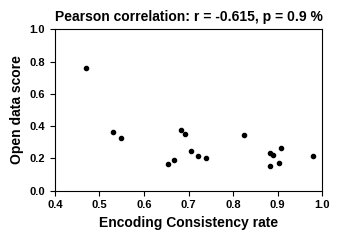

In [8]:
fig = plt.figure(figsize=(3.5, 2.5))

plt.plot(inconsitency_list, score_list, ".k")
plt.title(f"Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")
plt.xlabel("Encoding Consistency rate")
plt.ylabel("Open data score")
plt.xlim((0.4, 1.0))
plt.ylim((0.0, 1.0))
plt.tight_layout()

fig.savefig("../../data/processed/policy_vs_consistency.pdf")

## Sensitivity analysis: outlier removal

Recalculate the correlation after removing outlier publishers.

In [9]:
#remove outliers and recalculate Pearson correlation coefficient
inconsitency_list_filtered = []
score_list_filtered = []
for inconsitency, score in zip(inconsitency_list, score_list):
    if score < 0.75:  # Example threshold to remove outliers
        inconsitency_list_filtered.append(inconsitency)
        score_list_filtered.append(score)
r, p_value = stats.pearsonr(inconsitency_list_filtered, score_list_filtered)
print(f"After removing outliers: Pearson correlation: r = {r:.3f}, p = {p_value*100:.1f} %")

After removing outliers: Pearson correlation: r = -0.455, p = 7.6 %
